In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

In [39]:
from google.colab import files
uploaded = files.upload()

Saving Dataset 2.csv to Dataset 2 (2).csv


In [40]:
df = pd.read_csv("Dataset 2 (1).csv")

In [41]:
## Part A: Dataset Understanding
##Q1.Load dataset and display first five records

print("First Five Records")
df.head()

First Five Records


,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22.0,Female,Basic,23.0,5.0,Comedy,13.0,353.0,No
1,1002,55.0,Male,Basic,9.0,4.0,Drama,14.0,317.0,Yes
2,1003,49.0,Male,Basic,8.0,3.0,Comedy,16.0,309.0,No
3,1004,39.0,Female,Premium,19.0,5.0,Drama,45.0,833.0,Yes
4,1005,38.0,Female,Premium,23.0,5.0,Sci-Fi,24.0,804.0,Yes


In [42]:
##Q2.Number of rows and columns

rows, cols = df.shape
print("Number of Rows:", rows)
print("Number of Columns:", cols)

Number of Rows: 751
Number of Columns: 10


In [43]:
##Q3.Display all column names

print("Column Names")
for col in df.columns:
    print(col)

Column Names
UserID
Age
Gender
SubscriptionType
WatchHoursPerWeek
DevicesUsed
FavoriteGenre
AdClicks
MonthlySpend
SubscriptionRenewed


In [44]:
##Q4. Identify numerical and categorical features

numerical_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(include='object').columns
print("Numerical Features:")
print(list(numerical_features))
print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']

Categorical Features:
['UserID', 'Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


In [45]:
##Q5.Check missing values

print("Missing Values")
df.isnull().sum()

Missing Values


,0
UserID,0
Age,1
Gender,1
SubscriptionType,2
WatchHoursPerWeek,1
DevicesUsed,1
FavoriteGenre,2
AdClicks,1
MonthlySpend,1
SubscriptionRenewed,1


In [46]:
### Part B: Exploratory Data Analysis
##Q6.Average age of users

average_age = df['Age'].mean()
print("Average Age:", round(average_age,2))

Average Age: 41.82


In [47]:
##Q7.Average watch hours per week

avg_watch_hours = df['WatchHoursPerWeek'].mean()
print("Average Watch Hours Per Week:", round(avg_watch_hours,2))

Average Watch Hours Per Week: 14.24


In [48]:
##Q8.Average monthly spending

avg_spend = df['MonthlySpend'].mean()
print("Average Monthly Spend:", round(avg_spend,2))


Average Monthly Spend: 689.91


SubscriptionType
Basic      342
Premium    278
VIP        129
Name: count, dtype: int64


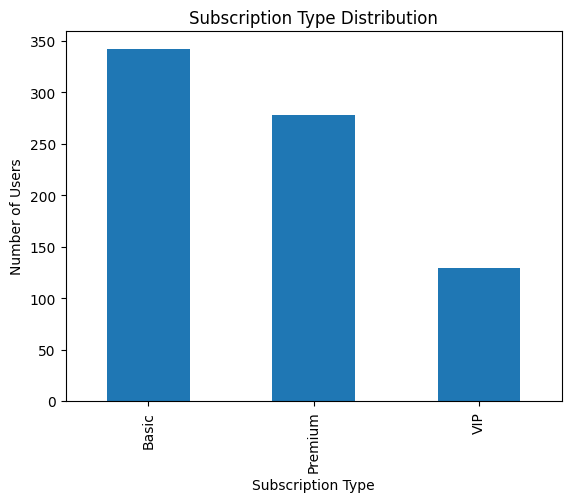

In [49]:
##Q9.Count users in each subscription category

subscription_count = df['SubscriptionType'].value_counts()
print(subscription_count)
subscription_count.plot(kind='bar')

plt.title("Subscription Type Distribution")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Users")

plt.show()

In [50]:
##Q10.Percentage of users who renewed subscription

renewal_percentage = ((df['SubscriptionRenewed'] == 'Yes').sum()/ len(df)) * 100
print("Renewal Percentage:", round(renewal_percentage,2), "%")

Renewal Percentage: 46.21 %


In [51]:
## Part C: Data Preparation
##Q11.Convert categorical features into numerical form

df_encoded = df.copy()
encoder = LabelEncoder()
categorical_columns = [
    'Gender',
    'SubscriptionType',
    'FavoriteGenre',
    'SubscriptionRenewed'
]
for col in categorical_columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
df_encoded.head()

df_encoded = df_encoded.fillna(df_encoded.mean(numeric_only=True))

In [52]:
##Q12.Define X and y

X = df_encoded.drop(
    ['UserID', 'SubscriptionRenewed'],
    axis=1
)
y = df_encoded['SubscriptionRenewed']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (751, 8)
Target Shape: (751,)


In [53]:
##Q13.Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 600
Testing Samples: 151


In [54]:
## Part D: Decision Tree Classification
##Q14.Train Decision Tree Model

dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [55]:
##Q15.Evaluate accuracy

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)
print("Decision Tree Accuracy:", round(dt_accuracy*100,2), "%")

Decision Tree Accuracy: 56.95 %


[[52 35]
 [30 34]]


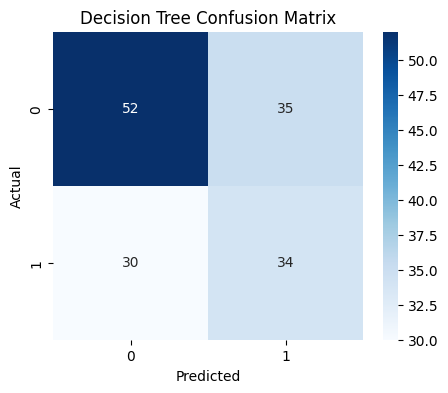

              precision    recall  f1-score   support

           0       0.63      0.60      0.62        87
           1       0.49      0.53      0.51        64

    accuracy                           0.57       151
   macro avg       0.56      0.56      0.56       151
weighted avg       0.57      0.57      0.57       151



In [56]:
##Q16.Confusion Matrix

cm = confusion_matrix(
    y_test,
    dt_predictions)
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
print(classification_report(
    y_test,
    dt_predictions))

In [57]:
## Part E: K-Nearest Neighbors (KNN)
##Q17. Train KNN (K=5)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [58]:
##Q18.Compare KNN and Decision Tree

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)
print("Decision Tree Accuracy:",
      round(dt_accuracy*100,2), "%")
print("KNN Accuracy:",
      round(knn_accuracy*100,2), "%")

if knn_accuracy > dt_accuracy:
    print("KNN performed better.")
else:
    print("Decision Tree performed better.")

Decision Tree Accuracy: 56.95 %
KNN Accuracy: 54.97 %
Decision Tree performed better.


In [57]:
## Part F: Linear Regression
##Q19.Train Linear Regression Model

X_reg = df_encoded.drop(
    ['UserID', 'MonthlySpend'],
    axis=1
)
y_reg = df_encoded['MonthlySpend']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)
lr_model = LinearRegression()
lr_model.fit(
    X_train_reg,
    y_train_reg
)
print("Linear Regression Model Trained Successfully")

In [57]:
##Q20.Predict Monthly Spending

sample_user = X_test_reg.iloc[[0]]
predicted_spend = lr_model.predict(sample_user)
print("Predicted Monthly Spend: ₹",
      round(predicted_spend[0],2))